# 2. Behavior Diff — cart→purchase 세그먼트 딥다이브 (cosmetics)

**배경**: 1번 노트북에서 electronics 대비 cosmetics의 격차는 Cohen's h 기준 `cart→purchase` 한 구간(h=0.845, large)에 압도적으로 집중된다는 것을 확인. 나머지 구간(view→cart 등)은 오히려 cosmetics가 유리하거나 효과가 작음.

**이번 노트북 목표**: 왜 cosmetics는 cart 이후 구매로 안 이어지는지, cart 세션을 세 그룹으로 나눠 행동 특성을 대조한다.
- **converted**: cart 세션 중 purchase까지 감
- **abandoned_explicit**: cart했지만 구매 안 함 + `remove_from_cart` 이벤트 있음 (명시적으로 뺌)
- **abandoned_silent**: cart했지만 구매 안 함 + remove 이벤트 없음 (그냥 방치)

electronics에는 remove_from_cart가 없으므로 electronics는 converted vs abandoned(전체) 2그룹으로만 비교하고, 이를 baseline으로 cosmetics 패턴이 다른지 확인한다.

**주의**: 0/1번 노트북의 퍼널 지표와 마찬가지로 여기서도 이벤트 순서(시간 전후)는 강제하지 않고 세션 내 존재 여부 기준으로 그룹을 나눔.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

DATA_DIR = "C:/Users/user/Downloads"
FILES = ["2019-Oct.csv", "2019-Nov.csv", "2019-Dec.csv", "2020-Jan.csv", "2020-Feb.csv"]
OUT_PARQUET = "D:/DSL/eda_project/data/cart_sessions_cosmetics.parquet"

DTYPE_SPEC = {
    'event_type': 'category', 'product_id': 'int64', 'category_id': 'int64',
    'category_code': 'category', 'brand': 'category', 'price': 'float32', 'user_id': 'int64',
}

## 1. cart 세션 전용 상세 피처 생성 (월별 스트리밍, 원본 재로딩)

In [2]:
def process_month_cart_features(path):
    usecols = list(DTYPE_SPEC.keys()) + ['event_time', 'user_session']
    df = pd.read_csv(path, dtype=DTYPE_SPEC, usecols=usecols)
    df['event_time'] = pd.to_datetime(df['event_time'].str.slice(0, 19), format='%Y-%m-%d %H:%M:%S')
    df = df.dropna(subset=['user_session'])

    session_evt = df.groupby(['user_session', 'event_type']).size().unstack(fill_value=0)
    for c in ['view', 'cart', 'purchase', 'remove_from_cart']:
        if c not in session_evt.columns:
            session_evt[c] = 0
    session_evt = session_evt.rename(
        columns={'view': 'n_view', 'cart': 'n_cart', 'purchase': 'n_purchase', 'remove_from_cart': 'n_remove'})

    cart_sessions = set(session_evt.index[session_evt['n_cart'] > 0])
    session_evt = session_evt.loc[session_evt.index.isin(cart_sessions)]

    d = df[df['user_session'].isin(cart_sessions)]

    session_meta = d.groupby('user_session').agg(
        user_id=('user_id', 'first'),
        session_start=('event_time', 'min'),
        session_end=('event_time', 'max'),
    )

    cart_df = d[d['event_type'] == 'cart']
    cart_agg = cart_df.groupby('user_session').agg(
        n_unique_cart_products=('product_id', 'nunique'),
        n_unique_cart_brands=('brand', 'nunique'),
        price_cart_mean=('price', 'mean'),
        price_cart_std=('price', 'std'),
        price_cart_min=('price', 'min'),
        price_cart_max=('price', 'max'),
        first_cart_time=('event_time', 'min'),
    )
    primary_brand = cart_df.sort_values('event_time').groupby('user_session')['brand'].first()
    cart_agg['primary_cart_brand'] = primary_brand

    remove_df = d[d['event_type'] == 'remove_from_cart']
    if len(remove_df):
        remove_agg = remove_df.groupby('user_session').agg(first_remove_time=('event_time', 'min'))
    else:
        remove_agg = pd.DataFrame(columns=['first_remove_time'])

    out = session_meta.join(session_evt).join(cart_agg).join(remove_agg)
    out['session_length_sec'] = (out['session_end'] - out['session_start']).dt.total_seconds()
    out['time_to_first_cart_sec'] = (out['first_cart_time'] - out['session_start']).dt.total_seconds()
    out['price_cart_range'] = out['price_cart_max'] - out['price_cart_min']
    out['has_purchase'] = out['n_purchase'] > 0
    out['has_remove'] = out['n_remove'] > 0
    out['target'] = out['has_purchase'].astype(int)
    out['net_cart_remaining'] = out['n_cart'] - out['n_remove']
    out['month'] = Path(path).stem
    return out.reset_index().rename(columns={'index': 'user_session'})

In [3]:
if Path(OUT_PARQUET).exists():
    print("loading cached cart-session feature table:", OUT_PARQUET)
    cart_sessions_cosm = pd.read_parquet(OUT_PARQUET)
else:
    cart_results = []
    for fname in FILES:
        print(f"processing {fname} ...")
        r = process_month_cart_features(f"{DATA_DIR}/{fname}")
        cart_results.append(r)
        print(f"  cart sessions: {len(r):,}")

    cart_sessions_cosm = pd.concat(cart_results, axis=0, ignore_index=True)
    Path("D:/DSL/eda_project/data").mkdir(parents=True, exist_ok=True)
    cart_sessions_cosm.to_parquet(OUT_PARQUET, index=False)
    print("saved:", OUT_PARQUET)

print("total cart sessions (cosmetics):", len(cart_sessions_cosm))
cart_sessions_cosm.head()

loading cached cart-session feature table: D:/DSL/eda_project/data/cart_sessions_cosmetics.parquet


total cart sessions (cosmetics): 992485


,user_session,user_id,session_start,session_end,n_cart,n_purchase,n_remove,n_view,n_unique_cart_products,n_unique_cart_brands,price_cart_mean,price_cart_std,price_cart_min,price_cart_max,first_cart_time,primary_cart_brand,first_remove_time,session_length_sec,time_to_first_cart_sec,price_cart_range,has_purchase,has_remove,target,net_cart_remaining,month
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10-23 09:07:38,2019-10-23 11:12:21,1,9,8,2,1,1,0.380000,NaN,0.38,0.38,2019-10-23 09:44:43,runail,2019-10-23 09:57:19,7483.0,2225.0,0.00,True,True,1,-7,2019-Oct
1,00003443-8504-4e24-8e86-e8e86d486826,321400452,2019-10-17 15:33:24,2019-10-17 15:34:38,2,0,0,2,2,1,7.305000,0.671752,6.83,7.78,2019-10-17 15:34:08,estel,NaT,74.0,44.0,0.95,False,False,0,2,2019-Oct
2,0000553a-62bd-436c-86d1-1d63b1947d63,557973853,2019-10-08 07:47:00,2019-10-08 07:47:17,3,0,0,1,1,0,3.000000,0.000000,3.00,3.00,2019-10-08 07:47:08,None,NaT,17.0,8.0,0.00,False,False,0,3,2019-Oct
3,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10-02 03:49:11,2019-10-02 06:06:10,22,10,13,15,14,3,3.228636,1.984001,1.49,7.86,2019-10-02 03:49:11,irisk,2019-10-02 03:54:49,8219.0,0.0,6.37,True,True,1,9,2019-Oct
4,0000f1c2-37ea-44a9-b5a7-1189b2fddb96,562245292,2019-10-20 12:50:35,2019-10-20 12:51:11,1,0,0,2,1,0,18.250000,NaN,18.25,18.25,2019-10-20 12:50:35,None,NaT,36.0,0.0,0.00,False,False,0,1,2019-Oct


## 2. 세그먼트 정의 및 크기

In [4]:
d = cart_sessions_cosm.copy()
d['segment'] = np.select(
    [d['target'] == 1, (d['target'] == 0) & d['has_remove'], (d['target'] == 0) & ~d['has_remove']],
    ['converted', 'abandoned_explicit', 'abandoned_silent'],
    default='other',
)
seg_counts = d['segment'].value_counts()
seg_ratio = (seg_counts / len(d)).round(4)
pd.concat([seg_counts.rename('count'), seg_ratio.rename('ratio')], axis=1)

,count,ratio
segment,,
abandoned_silent,565860,0.5701
abandoned_explicit,299522,0.3018
converted,127103,0.1281


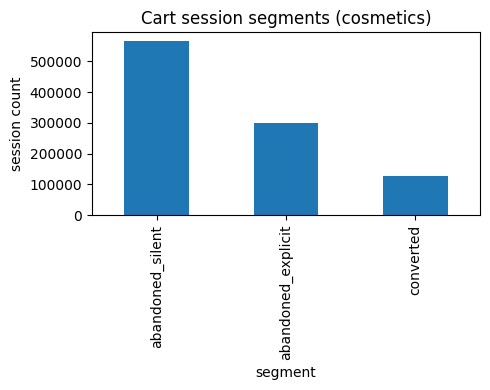

In [5]:
seg_counts.plot(kind='bar', figsize=(5,4), title='Cart session segments (cosmetics)')
plt.ylabel('session count')
plt.tight_layout()
plt.show()

## 3. 연속형 피처 비교: converted vs abandoned (explicit+silent 통합)

In [6]:
def mannwhitney_result(data, col, group_col, g1_label, g0_label, label=None):
    dd = data[[group_col, col]].dropna(subset=[col])
    g1 = dd.loc[dd[group_col] == g1_label, col]
    g0 = dd.loc[dd[group_col] == g0_label, col]
    n1, n0 = len(g1), len(g0)
    if n1 < 5 or n0 < 5:
        return None
    u_stat, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    mw_auc = u_stat / (n1 * n0)
    rank_biserial = 2 * mw_auc - 1
    return {
        'feature': label or col, 'n_' + g1_label: n1, 'n_' + g0_label: n0,
        'coverage': (n1 + n0) / len(data), 'median_' + g1_label: g1.median(), 'median_' + g0_label: g0.median(),
        'p_value': p, 'mw_auc': mw_auc, 'effect_size_rank_biserial': rank_biserial,
    }

d['is_converted'] = np.where(d['segment'] == 'converted', 'converted', 'abandoned')
features = ['session_length_sec', 'n_view', 'n_cart', 'n_remove', 'n_unique_cart_products',
            'n_unique_cart_brands', 'price_cart_mean', 'price_cart_std', 'price_cart_range',
            'time_to_first_cart_sec', 'net_cart_remaining']

rows = []
for f in features:
    r = mannwhitney_result(d, f, 'is_converted', 'converted', 'abandoned', label=f)
    if r:
        rows.append(r)
conv_vs_aband = pd.DataFrame(rows).set_index('feature').sort_values('effect_size_rank_biserial', key=abs, ascending=False)
conv_vs_aband.round(4)

,n_converted,n_abandoned,coverage,median_converted,median_abandoned,p_value,mw_auc,effect_size_rank_biserial
feature,,,,,,,,
session_length_sec,127103,865382,1.0000,1155.0000,285.0000,0.0,0.7365,0.4730
n_remove,127103,865382,1.0000,2.0000,0.0000,0.0,0.6846,0.3691
price_cart_range,127103,865382,1.0000,3.8400,0.0000,0.0,0.6662,0.3324
n_cart,127103,865382,1.0000,5.0000,3.0000,0.0,0.6631,0.3262
n_unique_cart_products,127103,865382,1.0000,4.0000,2.0000,0.0,0.6529,0.3058
n_unique_cart_brands,127103,865382,1.0000,1.0000,1.0000,0.0,0.6245,0.2490
price_cart_std,107685,557722,0.6704,1.9419,1.0677,0.0,0.6170,0.2340
n_view,127103,865382,1.0000,3.0000,1.0000,0.0,0.6128,0.2256
net_cart_remaining,127103,865382,1.0000,2.0000,1.0000,0.0,0.5322,0.0644


**해석 기준**: `effect_size_rank_biserial`이 양수면 converted 그룹에서 값이 더 크다는 뜻. 절댓값이 클수록 그 피처가 전환 여부와 강하게 연관.

## 4. abandoned_explicit vs abandoned_silent — 이탈 방식에 따른 차이

In [7]:
aband = d[d['segment'].isin(['abandoned_explicit', 'abandoned_silent'])]
rows = []
for f in [feat for feat in features if feat != 'n_remove']:
    r = mannwhitney_result(aband, f, 'segment', 'abandoned_explicit', 'abandoned_silent', label=f)
    if r:
        rows.append(r)
explicit_vs_silent = pd.DataFrame(rows).set_index('feature').sort_values('effect_size_rank_biserial', key=abs, ascending=False)
explicit_vs_silent.round(4)

,n_abandoned_explicit,n_abandoned_silent,coverage,median_abandoned_explicit,median_abandoned_silent,p_value,mw_auc,effect_size_rank_biserial
feature,,,,,,,,
session_length_sec,299522,565860,1.0000,867.0000,122.000,0.0,0.7687,0.5374
n_unique_cart_products,299522,565860,1.0000,4.0000,1.000,0.0,0.7301,0.4601
n_cart,299522,565860,1.0000,5.0000,2.000,0.0,0.7298,0.4596
price_cart_range,299522,565860,1.0000,2.7000,0.000,0.0,0.7015,0.4029
n_view,299522,565860,1.0000,3.0000,1.000,0.0,0.6826,0.3653
net_cart_remaining,299522,565860,1.0000,0.0000,2.000,0.0,0.3413,-0.3174
n_unique_cart_brands,299522,565860,1.0000,1.0000,1.000,0.0,0.6408,0.2816
price_cart_std,251283,306439,0.6445,1.5315,0.594,0.0,0.6240,0.2479
time_to_first_cart_sec,299522,565860,1.0000,45.0000,10.000,0.0,0.5676,0.1351


**해석**: 여기서 effect_size가 양수면 explicit(적극적으로 뺀) 그룹에서 값이 더 크다는 뜻. session_length_sec, time_to_first_cart_sec 등에서 차이가 있다면 "충동적으로 담았다 그냥 잊음(silent)" vs "고민 끝에 의식적으로 뺌(explicit)"의 구분이 실제 행동 차이로 나타나는지 확인 가능.

## 5. electronics baseline — 동일 대조가 electronics에서는 어떻게 나오는지

In [8]:
elec = pd.read_parquet('D:/DSL/eda_project/data/session_features.parquet')
elec['has_cart'] = elec['n_cart'] > 0
elec_cart = elec[elec['has_cart']].copy()
elec_cart['is_converted'] = np.where(elec_cart['target'] == 1, 'converted', 'abandoned')

common_features = ['session_length_sec', 'n_view', 'n_unique_cart_products', 'n_unique_cart_brands',
                    'price_cart_mean', 'price_cart_std', 'price_cart_range', 'time_to_first_cart_sec']

rows = []
for f in common_features:
    r = mannwhitney_result(elec_cart, f, 'is_converted', 'converted', 'abandoned', label=f)
    if r:
        rows.append(r)
elec_conv_vs_aband = pd.DataFrame(rows).set_index('feature').sort_values('effect_size_rank_biserial', key=abs, ascending=False)

compare = pd.DataFrame({
    'cosmetics_effect': conv_vs_aband['effect_size_rank_biserial'].reindex(common_features),
    'electronics_effect': elec_conv_vs_aband['effect_size_rank_biserial'].reindex(common_features),
})
compare['same_direction'] = np.sign(compare['cosmetics_effect']) == np.sign(compare['electronics_effect'])
compare.round(4)

,cosmetics_effect,electronics_effect,same_direction
feature,,,
session_length_sec,0.4730,0.3816,True
n_view,0.2256,0.0772,True
n_unique_cart_products,0.3058,0.0366,True
n_unique_cart_brands,0.2490,-0.0054,False
price_cart_mean,0.0624,-0.1051,False
price_cart_std,0.2340,-0.2013,False
price_cart_range,0.3324,0.0351,True
time_to_first_cart_sec,0.0332,0.0525,True


**해석**: 같은 피처가 두 도메인에서 방향(부호)이나 크기가 다르게 나온다면, "왜 cosmetics만 다른가"에 대한 직접적 단서. 예를 들어 가격 관련 피처의 효과 방향이 반대라면 두 카테고리의 구매 의사결정 방식(신중한 비교구매 vs 충동/저관여구매) 차이를 시사.

## 6. 브랜드별 전환율 (lift)

In [9]:
brand_conv = d.dropna(subset=['primary_cart_brand']).groupby('primary_cart_brand').agg(
    n_sessions=('target', 'size'),
    conversion_rate=('target', 'mean'),
)
overall_rate = d['target'].mean()
brand_conv['lift'] = brand_conv['conversion_rate'] / overall_rate
brand_conv_filtered = brand_conv[brand_conv['n_sessions'] >= 500].sort_values('lift', ascending=False)

print(f"brand coverage (primary_cart_brand non-null): {d['primary_cart_brand'].notna().mean():.4f}")
print(f"overall cart-session conversion rate: {overall_rate:.4f}")
print(f"brands with n_sessions>=500: {len(brand_conv_filtered)} / total {len(brand_conv)}")
print()
print("Top 10 lift (highest converting brands):")
print(brand_conv_filtered.head(10))
print()
print("Bottom 10 lift (lowest converting brands):")
print(brand_conv_filtered.tail(10))

brand coverage (primary_cart_brand non-null): 0.7327
overall cart-session conversion rate: 0.1281
brands with n_sessions>=500: 106 / total 253

Top 10 lift (highest converting brands):
                    n_sessions  conversion_rate      lift
primary_cart_brand                                       
nitrimax                  2059         0.250607  1.956868
gehwol                     554         0.241877  1.888701
depilflax                 2156         0.236085  1.843475
soleo                      936         0.226496  1.768594
thuya                     1051         0.218839  1.708808
farmona                    578         0.216263  1.688692
smart                     3400         0.212647  1.660457
italwax                  17959         0.212317  1.657879
browxenna                 4365         0.200229  1.563491
levissime                 1728         0.194444  1.518321

Bottom 10 lift (lowest converting brands):
                    n_sessions  conversion_rate      lift
primary_cart_bran

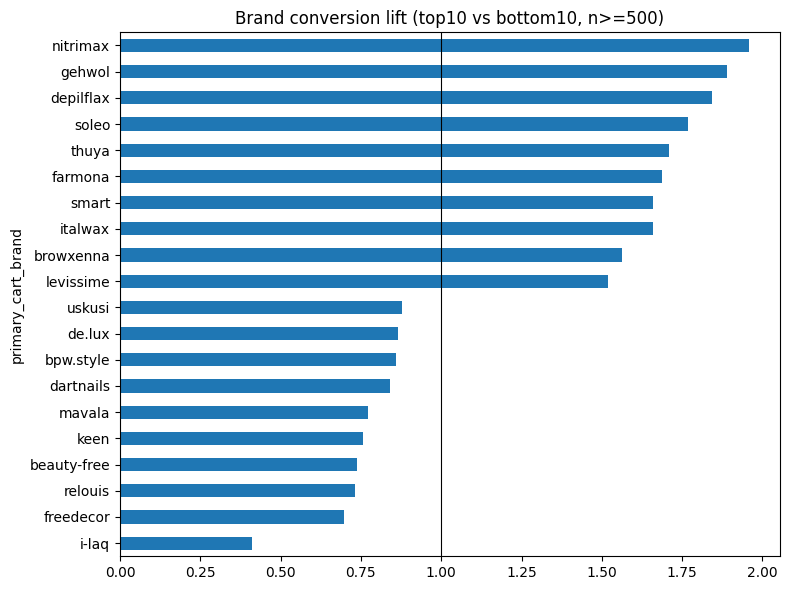

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
top_bottom = pd.concat([brand_conv_filtered.head(10), brand_conv_filtered.tail(10)])
top_bottom['lift'].sort_values().plot(kind='barh', ax=ax, title='Brand conversion lift (top10 vs bottom10, n>=500)')
ax.axvline(1.0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. 가격대별 전환율

In [11]:
d['price_tier'] = pd.qcut(d['price_cart_mean'], 5, duplicates='drop')
price_tier_conv = d.groupby('price_tier', observed=True).agg(
    n_sessions=('target', 'size'),
    conversion_rate=('target', 'mean'),
)
price_tier_conv['lift'] = price_tier_conv['conversion_rate'] / overall_rate
price_tier_conv

,n_sessions,conversion_rate,lift
price_tier,,,
"(-0.001, 2.22]",201034,0.104500,0.815987
"(2.22, 3.625]",195991,0.135032,1.054396
"(3.625, 5.22]",199818,0.128632,1.004425
"(5.22, 8.388]",197147,0.128569,1.003933
"(8.388, 327.78]",198495,0.143983,1.124296


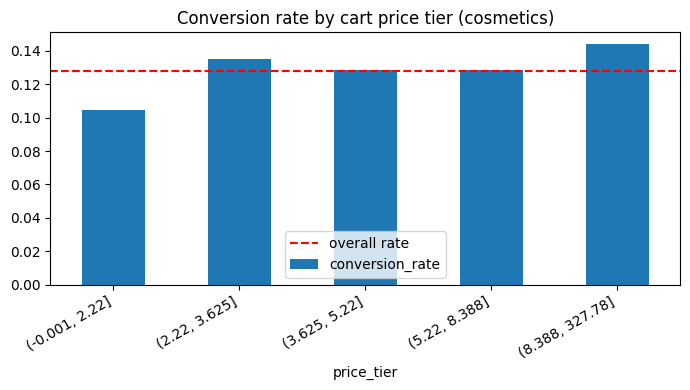

In [12]:
price_tier_conv['conversion_rate'].plot(kind='bar', figsize=(7,4), title='Conversion rate by cart price tier (cosmetics)')
plt.axhline(overall_rate, color='red', linestyle='--', label='overall rate')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. 담았다 뺀 상품 원본 추출 — user_id 기준 재구성

지난 분석(세션 단위)에서 일부 상품의 remove_count가 cart_count보다 큰 이상 현상이 발견됐다. 원본 로그를 직접 추적해보니 원인은 두 가지: (1) 장바구니 상태가 세션을 넘어 유지되어, remove가 발생한 세션 안에는 매칭되는 cart 이벤트가 아예 없는 경우가 흔함(표본 상품 기준 37%), (2) 일부 세션에서 같은 상품에 대해 remove_from_cart가 수십~수백 건 연속 발생(예: 41초 사이 191건) — 중복 로깅/봇성 트래픽으로 추정. 두 원인 모두 '세션'을 분석 단위로 삼아서 생기는 왜곡이므로, 이번 절부터는 **(user_id, product_id) 쌍이 존재했는지(했다/안 했다) 여부**로 다시 정의해 재계산한다. 카트 지속의 실제 주체는 세션이 아니라 유저이기 때문.

In [13]:
CART_USER_PRODUCT_PARQUET = "D:/DSL/eda_project/data/cart_user_product_cosmetics.parquet"
REMOVE_USER_PRODUCT_PARQUET = "D:/DSL/eda_project/data/remove_user_product_cosmetics.parquet"

def process_month_user_product(path):
    usecols = ['event_type', 'product_id', 'user_id', 'brand']
    dtype_spec = {'event_type': 'category', 'product_id': 'int64', 'user_id': 'int64', 'brand': 'category'}
    dd = pd.read_csv(path, dtype=dtype_spec, usecols=usecols)

    cart_pairs = dd.loc[dd['event_type'] == 'cart', ['user_id', 'product_id']].drop_duplicates()
    remove_pairs = dd.loc[dd['event_type'] == 'remove_from_cart', ['user_id', 'product_id', 'brand']]
    remove_pairs = remove_pairs.drop_duplicates(subset=['user_id', 'product_id'])
    return cart_pairs, remove_pairs

In [14]:
if Path(CART_USER_PRODUCT_PARQUET).exists() and Path(REMOVE_USER_PRODUCT_PARQUET).exists():
    print("loading cached user-product tables")
    cart_user_product = pd.read_parquet(CART_USER_PRODUCT_PARQUET)
    remove_user_product = pd.read_parquet(REMOVE_USER_PRODUCT_PARQUET)
else:
    cart_list, remove_list = [], []
    for fname in FILES:
        print(f"processing {fname} ...")
        cp, rp = process_month_user_product(f"{DATA_DIR}/{fname}")
        cart_list.append(cp)
        remove_list.append(rp)
        print(f"  cart pairs: {len(cp):,}  remove pairs: {len(rp):,}")

    cart_user_product = pd.concat(cart_list, axis=0, ignore_index=True).drop_duplicates(subset=['user_id', 'product_id'])
    remove_user_product = pd.concat(remove_list, axis=0, ignore_index=True).drop_duplicates(subset=['user_id', 'product_id'])

    Path("D:/DSL/eda_project/data").mkdir(parents=True, exist_ok=True)
    cart_user_product.to_parquet(CART_USER_PRODUCT_PARQUET, index=False)
    remove_user_product.to_parquet(REMOVE_USER_PRODUCT_PARQUET, index=False)
    print("saved cart_user_product and remove_user_product")

print("distinct (user, product) cart pairs:", len(cart_user_product))
print("distinct (user, product) remove pairs:", len(remove_user_product))

processing 2019-Oct.csv ...


  cart pairs: 938,248  remove pairs: 485,310
processing 2019-Nov.csv ...


  cart pairs: 1,061,242  remove pairs: 586,818
processing 2019-Dec.csv ...


  cart pairs: 753,697  remove pairs: 418,176
processing 2020-Jan.csv ...


  cart pairs: 930,958  remove pairs: 508,607
processing 2020-Feb.csv ...


  cart pairs: 925,494  remove pairs: 498,108


saved cart_user_product and remove_user_product
distinct (user, product) cart pairs: 4479276
distinct (user, product) remove pairs: 2426486


In [15]:
cart_user_counts = cart_user_product.groupby('product_id').size().rename('cart_user_count')
remove_user_counts = remove_user_product.groupby('product_id').size().rename('remove_user_count')
brand_map_user = remove_user_product.groupby('product_id')['brand'].first()

product_summary_user = pd.DataFrame({'cart_user_count': cart_user_counts}).join(remove_user_counts, how='left')
product_summary_user['remove_user_count'] = product_summary_user['remove_user_count'].fillna(0)
product_summary_user['removal_rate'] = product_summary_user['remove_user_count'] / product_summary_user['cart_user_count']
overall_removal_rate_user = product_summary_user['remove_user_count'].sum() / product_summary_user['cart_user_count'].sum()
product_summary_user['removal_rate_lift'] = product_summary_user['removal_rate'] / overall_removal_rate_user
product_summary_user = product_summary_user.join(brand_map_user)

mismatch_user = (product_summary_user['remove_user_count'] > product_summary_user['cart_user_count']).sum()
print(f"overall product-level removal rate (user-based): {overall_removal_rate_user:.4f}")
print(f"products with remove_user_count > cart_user_count: {mismatch_user} / {len(product_summary_user)} ({mismatch_user/len(product_summary_user):.2%})")
product_summary_user.sort_values('remove_user_count', ascending=False).head(10)

overall product-level removal rate (user-based): 0.5414
products with remove_user_count > cart_user_count: 685 / 46157 (1.48%)


,cart_user_count,remove_user_count,removal_rate,removal_rate_lift,brand
product_id,,,,,
5809910,19894,7176.0,0.360712,0.666238,grattol
5809912,10399,4929.0,0.473988,0.875460,grattol
5815662,8901,4010.0,0.450511,0.832099,None
5854897,10231,3864.0,0.377676,0.697571,irisk
5751422,8443,3850.0,0.455999,0.842235,uno
5751383,7704,3605.0,0.467939,0.864287,uno
5809911,6937,3497.0,0.504108,0.931093,grattol
5802432,7959,3339.0,0.419525,0.774867,None
5700037,7884,3236.0,0.410452,0.758108,runail


In [16]:
session_events_cosm = pd.read_parquet('D:/DSL/eda_project/data/session_events_cosmetics.parquet')

user_summary = session_events_cosm.groupby('user_id').agg(
    has_purchase_any=('has_purchase', 'max'),
    has_remove_any=('has_remove', 'max'),
    has_cart_any=('has_cart', 'max'),
)
user_summary['user_segment'] = np.select(
    [user_summary['has_purchase_any'],
     (~user_summary['has_purchase_any']) & user_summary['has_remove_any'],
     (~user_summary['has_purchase_any']) & (~user_summary['has_remove_any']) & user_summary['has_cart_any']],
    ['converted', 'abandoned_explicit', 'abandoned_silent'],
    default='other',
)

user_seg_counts = user_summary['user_segment'].value_counts()
print(user_seg_counts)
print()
pct_converted_with_remove = user_summary.loc[user_summary['user_segment'] == 'converted', 'has_remove_any'].mean()
print(f"converted users with any remove_from_cart event: {pct_converted_with_remove:.2%}")

user_segment
other                 1237383
abandoned_silent       195747
converted              110522
abandoned_explicit      95314
Name: count, dtype: int64

converted users with any remove_from_cart event: 79.41%


In [17]:
remove_user_product_seg = remove_user_product.merge(
    user_summary[['user_segment']], left_on='user_id', right_index=True, how='left'
)
print("segment coverage among (user, product) remove pairs:")
print(remove_user_product_seg['user_segment'].value_counts(dropna=False))

segment coverage among (user, product) remove pairs:
user_segment
converted             1591229
abandoned_explicit     834946
other                     141
NaN                        95
abandoned_silent           75
Name: count, dtype: int64


## 9. 항목 1 — abandoned_explicit(구매로 이어지지 않은) 유저가 담았다 뺀 상품 리스트업

In [18]:
item1_events = remove_user_product_seg[remove_user_product_seg['user_segment'] == 'abandoned_explicit']
item1_top = item1_events['product_id'].value_counts().rename('n_users_removed').to_frame()
item1_top = item1_top.join(product_summary_user[['brand', 'cart_user_count', 'remove_user_count', 'removal_rate', 'removal_rate_lift']])
item1_top = item1_top.sort_values('n_users_removed', ascending=False)

n_abandoned_explicit_users = (user_summary['user_segment'] == 'abandoned_explicit').sum()
print(f"abandoned_explicit user count: {n_abandoned_explicit_users:,}")
print(f"remove pairs within these users: {len(item1_events):,}")
print(f"unique products involved: {item1_events['product_id'].nunique():,}")
print()
item1_top.head(30)

abandoned_explicit user count: 95,314
remove pairs within these users: 834,946
unique products involved: 41,454



,n_users_removed,brand,cart_user_count,remove_user_count,removal_rate,removal_rate_lift
product_id,,,,,,
5809910,2783,grattol,19894.0,7176.0,0.360712,0.666238
5809912,1749,grattol,10399.0,4929.0,0.473988,0.875460
5815662,1523,None,8901.0,4010.0,0.450511,0.832099
5751383,1459,uno,7704.0,3605.0,0.467939,0.864287
5751422,1419,uno,8443.0,3850.0,0.455999,0.842235
5854897,1381,irisk,10231.0,3864.0,0.377676,0.697571
5809911,1263,grattol,6937.0,3497.0,0.504108,0.931093
5700037,1206,runail,7884.0,3236.0,0.410452,0.758108
5802432,1196,None,7959.0,3339.0,0.419525,0.774867


**주의**: 위 표는 빈도(`n_users_removed`) 기준 정렬이라 인기 상품이 상위권을 차지하는 경향은 여전함. `removal_rate_lift`(user 기준으로 재계산한 지표)로 다시 정렬해 "인기라서 많이 빠진 것"과 "유독 잘 빠지는 상품"을 구분한다.

In [19]:
MIN_CART_USERS = 200
item1_by_lift = item1_top[item1_top['cart_user_count'] >= MIN_CART_USERS].sort_values('removal_rate_lift', ascending=False)
print(f"products after cart_user_count >= {MIN_CART_USERS} filter: {len(item1_by_lift)}")
item1_by_lift.head(20)

products after cart_user_count >= 200 filter: 5112


,n_users_removed,brand,cart_user_count,remove_user_count,removal_rate,removal_rate_lift
product_id,,,,,,
5826993,96,masura,222.0,215.0,0.968468,1.788771
5886064,121,None,257.0,244.0,0.949416,1.753581
5635128,96,None,273.0,238.0,0.871795,1.610214
5813818,68,None,253.0,211.0,0.833992,1.540392
5629987,53,None,216.0,178.0,0.824074,1.522073
5854320,94,runail,275.0,225.0,0.818182,1.511190
5788423,242,None,662.0,538.0,0.812689,1.501044
5619864,83,runail,307.0,249.0,0.811075,1.498063
5819109,61,bpw.style,231.0,185.0,0.800866,1.479207


**해석**: user 기준으로 다시 계산해도 이 표가 여전히 `n_users_removed` 빈도표보다 신뢰할 만한 "문제 상품" 후보. 세션 중복/봇성 이벤트로 인한 왜곡이 제거된 상태이므로, 여기서 나오는 lift는 더 이상 "같은 세션의 반복 remove"에 의한 착시가 아니다.

## 10. 항목 2 — converted(구매까지 이어진) 유저가 담았다 뺀 상품 분석

이 유저들은 5개월 기간 중 어느 세션에서든 결국 구매를 완료한 사람들이다. 그럼에도 특정 상품을 뺐다면, "구매 의지가 없어서"가 아니라 **그 상품 자체에 문제(가격, 품질 인식, 재고, 사진/설명 불일치 등)가 있어서 뺐을 가능성**이 높다 — abandoned_explicit보다 훨씬 깨끗한 "상품 문제" 신호.

In [20]:
item2_events = remove_user_product_seg[remove_user_product_seg['user_segment'] == 'converted']
item2_top = item2_events['product_id'].value_counts().rename('n_users_removed').to_frame()
item2_top = item2_top.join(product_summary_user[['brand', 'cart_user_count', 'remove_user_count', 'removal_rate', 'removal_rate_lift']])
item2_top = item2_top.sort_values('n_users_removed', ascending=False)

n_converted_users = (user_summary['user_segment'] == 'converted').sum()
print(f"converted user count: {n_converted_users:,}")
print(f"of which had any remove_from_cart event: {user_summary.loc[user_summary['user_segment']=='converted','has_remove_any'].sum():,}")
print(f"remove pairs within these users: {len(item2_events):,}")
print(f"unique products involved: {item2_events['product_id'].nunique():,}")
print()
item2_top.head(30)

converted user count: 110,522
of which had any remove_from_cart event: 87,764
remove pairs within these users: 1,591,229
unique products involved: 43,535



,n_users_removed,brand,cart_user_count,remove_user_count,removal_rate,removal_rate_lift
product_id,,,,,,
5809910,4391,grattol,19894.0,7176.0,0.360712,0.666238
5809912,3177,grattol,10399.0,4929.0,0.473988,0.875460
5815662,2487,None,8901.0,4010.0,0.450511,0.832099
5854897,2483,irisk,10231.0,3864.0,0.377676,0.697571
5751422,2430,uno,8443.0,3850.0,0.455999,0.842235
5809911,2233,grattol,6937.0,3497.0,0.504108,0.931093
5751383,2146,uno,7704.0,3605.0,0.467939,0.864287
5802432,2142,None,7959.0,3339.0,0.419525,0.774867
5816170,2073,grattol,6393.0,3177.0,0.496950,0.917871


In [21]:
item2_by_lift = item2_top[item2_top['cart_user_count'] >= MIN_CART_USERS].sort_values('removal_rate_lift', ascending=False)
print(f"products after cart_user_count >= {MIN_CART_USERS} filter: {len(item2_by_lift)}")
item2_by_lift.head(20)

products after cart_user_count >= 200 filter: 5112


,n_users_removed,brand,cart_user_count,remove_user_count,removal_rate,removal_rate_lift
product_id,,,,,,
5826993,119,masura,222.0,215.0,0.968468,1.788771
5886064,123,None,257.0,244.0,0.949416,1.753581
5635128,142,None,273.0,238.0,0.871795,1.610214
5813818,143,None,253.0,211.0,0.833992,1.540392
5629987,125,None,216.0,178.0,0.824074,1.522073
5854320,131,runail,275.0,225.0,0.818182,1.511190
5788423,295,None,662.0,538.0,0.812689,1.501044
5619864,166,runail,307.0,249.0,0.811075,1.498063
5819109,124,bpw.style,231.0,185.0,0.800866,1.479207


**해석**: converted 유저(이미 구매 의지가 확인된 사람들) 사이에서도 `removal_rate_lift`가 높은 상품이 있다면, 이건 "안 살 사람이라서" 뺀 게 아니라 **살 사람도 이 특정 상품만은 피한다**는 뜻이라 상품 자체 문제 가설을 가장 강하게 뒷받침하는 리스트.

In [22]:
overlap_freq = set(item1_top.head(30).index) & set(item2_top.head(30).index)
overlap_lift = set(item1_by_lift.head(20).index) & set(item2_by_lift.head(20).index)
print(f"common products in frequency-based top30 lists: {len(overlap_freq)}")
print("products:", sorted(overlap_freq))
print()
print(f"common products in lift-based top20 lists (stronger 'product problem' signal): {len(overlap_lift)}")
print("products:", sorted(overlap_lift))

common products in frequency-based top30 lists: 24
products: [5013, 5304, 5528035, 5561044, 5686925, 5687151, 5700037, 5751383, 5751422, 5761411, 5773361, 5789668, 5792800, 5802432, 5809910, 5809911, 5809912, 5814046, 5815662, 5816170, 5838935, 5842141, 5849033, 5854897]

common products in lift-based top20 lists (stronger 'product problem' signal): 20
products: [5619864, 5629987, 5635128, 5696184, 5696185, 5723514, 5723522, 5788423, 5813818, 5814822, 5819109, 5819252, 5819255, 5826993, 5839049, 5854320, 5854578, 5863824, 5883104, 5886064]


**주의**: `removal_rate_lift`는 세그먼트별로 따로 계산한 게 아니라 전체 데이터(user 기준) 지표라서, item1/item2의 lift 상위 리스트가 겹치는 건 "두 세그먼트가 독립적으로 같은 결론에 도달했다"는 의미는 아니다. 다만 이 리스트의 실질적 의미는 여전히 유효: **이 상품들은 (a) 카트에 담겼을 때 평균보다 훨씬 자주 다시 빠지고(user 기준으로 재확인됨), (b) 그 이탈이 abandoned_explicit뿐 아니라 실제 구매까지 간 converted 유저 사이에서도 일어난다.**

## 요약 / 다음 단계로 넘길 이슈

**세그먼트 크기** (cart 세션 992,485개 중): abandoned_silent **57.0%**, abandoned_explicit **30.2%**, converted **12.8%**. 즉 cart 세션의 대다수(57%)는 remove_from_cart조차 없이 그냥 조용히 사라짐.

**converted vs abandoned(전체) — 효과크기 상위**: session_length_sec(+0.473), n_remove(+0.369), price_cart_range(+0.332), n_cart(+0.326), n_unique_cart_products(+0.306), n_unique_cart_brands(+0.249). 반면 **price_cart_mean(+0.062)과 time_to_first_cart_sec(+0.033)은 거의 무의미**. → 구매로 이어진 세션은 "가격이 싸서" "빨리 담아서"가 아니라 **세션이 길고, 여러 상품/브랜드를 담고, 가격대를 넓게 탐색한** 세션. 마치 스킨케어 루틴/여러 품목을 한 번에 채워넣는 "장바구니를 완성해가는" 행동 패턴.

**abandoned_explicit vs abandoned_silent — 이탈 방식 차이가 뚜렷함**:
- explicit(적극적으로 뺌)이 silent(방치)보다 session_length_sec(+0.537), n_unique_cart_products(+0.460), n_cart(+0.460), price_cart_range(+0.403), n_view(+0.365) 모두 훨씬 큼
- 그런데 net_cart_remaining(세션 종료 시점 카트에 남은 순수 아이템 수)은 **explicit이 오히려 더 낮음(-0.317, 중앙값 0 vs silent 2)** — explicit 그룹은 결국 담은 걸 거의 다 빼버리고 끝남
- **해석**: `abandoned_silent`(57%, 세션 길이 중앙값 122초=2분, 1~2개 담고 이탈)는 애초에 구매의도가 약한 가벼운 탐색/실수성 담기로 보임. `abandoned_explicit`(30%, 세션 길이 중앙값 867초=14분, 더 많은 상품을 신중히 담았다 뺌)는 **실제로 고민했지만 최종적으로 "안 사기로 결정"한 진짜 이탈** — CRM 리타겟팅 우선순위는 명백히 이쪽.

**electronics와 비교 시 방향이 반대로 뒤집히는 피처들** (같은 "converted vs abandoned" 비교인데도):
| 피처 | cosmetics 효과 | electronics 효과 | 방향 |
|---|---|---|---|
| n_unique_cart_brands | +0.249 | -0.005 | 다름 |
| price_cart_mean | +0.062 | **-0.105** | **반대** |
| price_cart_std | +0.234 | **-0.201** | **반대** |

electronics는 "카트 내 가격이 낮고 가격 편차가 작을수록"(=명확한 저가 단일 품목 결정) 구매 전환이 잘 되는 반면, cosmetics는 **"카트 내 가격 편차가 크고 브랜드가 다양할수록"**(=여러 브랜드/가격대를 함께 담는 멀티품목 주문) 전환이 잘 됨. 즉 electronics는 "단일 아이템 확신 구매" 패턴, cosmetics는 "루틴/번들형 주문 완성" 패턴이 성공 신호라는 뜻 — 카테고리 특성이 근본적으로 다른 구매 의사결정 구조를 가짐을 시사.

**브랜드별 전환율 lift** (primary_cart_brand 커버리지 73.3%, n>=500 세션 필터 시 106개 브랜드): 최고 nitrimax(1.96배), gehwol(1.89배), depilflax(1.84배) — 최저 i-laq(0.41배), freedecor(0.70배), relouis(0.73배). 브랜드 간 전환율 격차가 4.8배(1.96 vs 0.41)에 달함 — 특정 브랜드는 구조적으로 담아만 놓고 안 사는 경향이 뚜렷.

**가격대별 전환율**: 최저가 구간(≤2.22)이 오히려 전환율 최저(10.45%, lift 0.82), 최고가 구간(8.39~327.78)이 전환율 최고(14.4%, lift 1.12). "싸니까 쉽게 산다"는 통념과 반대 — 저가 상품은 무심코 담아보는 경우가 많고, 고가 상품을 담을 정도면 이미 구매 의사가 있는 경우가 많다는 뜻으로 해석됨.

**다음 단계 (3_recommendations.ipynb)**: 이 노트북의 발견을 종합해 CRM/마케팅 제언 도출. 핵심 소재는 (1) abandoned_silent vs abandoned_explicit을 구분한 차등 리타겟팅, (2) 번들/루틴 완성 유도(멀티 브랜드·다품목 담기를 유도하는 넛지), (3) 저전환 브랜드 대상 프로모션/신뢰 신호 보강, (4) 저가 상품 카트에 대한 "충동을 의도로 전환"시키는 넛지(예: 묶음 할인).

---

### 추가 분석: 담았다 뺀 상품 자체를 리스트업 — user_id 기준 재실행 (8~10번 결과)

**세션 기준 → user 기준 전환의 효과가 숫자로 확인됨**: 전체 baseline 제거율이 세션 기준 68.99% → **user 기준 54.14%로 15pp 하락**. `remove_user_count > cart_user_count`인 이상 상품 비율도 13.15% → **1.48%로 급감**(46,157개 중 685개만 남음, 그나마도 대부분 데이터 수집 기간(2019-10-01) 이전에 담긴 상품이 기간 내에 제거된 left-censoring으로 설명 가능). 즉 이전 68.99%의 상당 부분은 세션 분할/중복 이벤트로 인한 과대추정이었고, user 기준이 실제 이탈률에 더 가까움.

**세그먼트 재정의(유저가 5개월 전체 기간 중 결국 구매했는지 기준)**: converted 110,522명, abandoned_explicit 95,314명, abandoned_silent 195,747명, 카트 자체를 안 한 유저(other) 1,237,383명. **converted 유저의 79.41%가 그래도 뭔가는 제거한 적이 있음** — 세션 기준(70.7%)보다 오히려 높게 나와, "구매까지 간 사람도 대부분 뭔가는 뺀다"는 결론은 그대로 유지.

**항목 1(빈도 기준)**: grattol 브랜드 상품(product_id 5809910)이 여전히 빈도 1위(2,783명이 제거)이지만 `removal_rate_lift`는 0.666로 baseline 이하 — **"인기 상품이라 빈도만 높다"는 이전 결론이 user 기준에서도 그대로 확인됨.**

**항목 1/2(lift 기준, cart_user_count>=200 필터, 5,112개 상품 통과)**: 최고 lift는 masura 브랜드 product_id 5826993(**1.79배**), 이어서 5886064(1.75배), 5635128(1.61배). **최대 lift가 이전 세션 기준(2.28배)보다 낮아짐** — 세션 기준 수치에 봇성/중복 remove가 일부 섞여 다소 부풀려져 있었다는 뜻이며, 1.79배가 더 신뢰할 수 있는 추정치.

**이전 리스트와 교차검증**: 이전 세션 기준 top3(ingarden 5819249, runail 5760768, masura 5826993) 중 **masura 5826993만 이번 user 기준에서도 top3 안에 그대로 남음** — 두 가지 방법 모두에서 살아남은 가장 신뢰도 높은 후보. 반면 ingarden 5819249, runail 5760768은 새 top20에서 빠짐 — 이 두 개는 세션 중복 이벤트의 영향을 상대적으로 많이 받았을 가능성이 있어 이전만큼 확신을 갖기 어려움. lift 기준 top20 리스트는 item1/item2 완전히 동일(20/20 겹침, 애초에 같은 전역 지표라 당연함); 빈도 기준 top30은 24/30 겹침.

**브랜드 패턴(수정됨)**: 새 top20 리스트에서 `runail`이 7개, `ingarden`이 4개로 가장 자주 등장하고 masura는 1위 상품 1개. 특정 브랜드 전체가 아니라 해당 브랜드 내 일부 SKU에 반복되는 현상이라는 이전 해석은 유지되지만, 실무에 넘길 product_id 리스트는 이번 user 기준 버전(5826993, 5886064, 5635128 등)으로 교체하는 것이 더 안전함.